In [1]:
cd '/Users/alaimo/Downloads/'

/Users/alaimo/Downloads


In [1]:
import xarray as xr
from erddapy import ERDDAP
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xroms
import pandas as pd
import numpy as np
from shapely.geometry import Point, Polygon

#### Load in the FishBot Data from ERDDAP

In [2]:
def get_erddap_dataset(ds_id, server, variables=None, constraints=None, filetype=None):
    ## Written by Mike Smith
    """
    Returns a netcdf dataset for a specified dataset ID (or dataframe if dataset cannot be converted to xarray)
    :param ds_id: dataset ID e.g. ng314-20200806T2040
    :param variables: optional list of variables
    :param constraints: optional list of constraints
    :param filetype: optional filetype to return, 'nc' (default) or 'dataframe'
    :return: netcdf dataset
    """
    variables = variables or None
    constraints = constraints or None
    filetype = filetype or 'nc'
    #ioos_url = 'https://data.ioos.us/gliders/erddap'


    e = ERDDAP(server,
               protocol='tabledap',
               response='nc')
    e.dataset_id = ds_id
    if constraints:
        e.constraints = constraints
    if variables:
        e.variables = variables
    if filetype == 'nc':
        try:
            ds = e.to_xarray()
            ds = ds.sortby(ds.time)
        except OSError:
            print('No dataset available for specified constraints: {}'.format(ds_id))
            ds = []
        except TypeError:
            print('Cannot convert to xarray, providing dataframe: {}'.format(ds_id))
            ds = e.to_pandas().dropna()
    elif filetype == 'dataframe':
        #ds = e.to_pandas().dropna()
        ds = e.to_pandas().dropna(how='all')
    else:
        print('Unrecognized filetype: {}. Needs to  be "nc" or "dataframe"'.format(filetype))

    return ds

In [3]:
variables = [
    'time',
    'temperature',
    'temperature_min',
    'temperature_max',
    'temperature_std',
    'temperature_count',
    'dissolved_oxygen',
    'dissolved_oxygen_min',
    'dissolved_oxygen_max',
    'dissolved_oxygen_std',
    'dissolved_oxygen_count',
    'salinity',
    'salinity_min',
    'salinity_max',
    'salinity_std',
    'salinity_count',
    'data_provider',
    'grid_id',
    'stat_area',
    'fishery_dependent',
    'depth',
    'latitude',
    'longitude'
]
ds_id = 'fishbot_realtime'
server = "https://erddap.ondeckdata.com/erddap/"

fishbot = get_erddap_dataset('fishbot_realtime',server =server,variables=variables,filetype='dataframe' )

In [4]:
## Clean up the column names
fishbot.columns = fishbot.columns = (
    fishbot.columns
    .str.replace(r"\s*\(.*?\)", "", regex=True)  # remove units in parentheses
    .str.strip()
    .str.replace(" ", "_")
)

In [5]:
fishbot

,time,temperature,temperature_min,temperature_max,temperature_std,temperature_count,dissolved_oxygen,dissolved_oxygen_min,dissolved_oxygen_max,dissolved_oxygen_std,...,salinity_max,salinity_std,salinity_count,data_provider,grid_id,stat_area,fishery_dependent,depth,latitude,longitude
0,2000-01-15T00:00:00Z,12.740000,12.740000,12.74000,NaN,1,NaN,NaN,NaN,NaN,...,NaN,NaN,0,Oleander,12452,616,0,73,39.483250,-72.703926
1,2000-01-15T00:00:00Z,10.480000,10.480000,10.48000,NaN,1,NaN,NaN,NaN,NaN,...,NaN,NaN,0,Oleander,11401,615,0,60,39.906998,-73.217834
2,2000-01-15T00:00:00Z,7.800000,7.800000,7.80000,NaN,1,NaN,NaN,NaN,NaN,...,NaN,NaN,0,Oleander,10525,612,0,23,40.268566,-73.651695
3,2000-01-15T00:00:00Z,8.110000,8.110000,8.11000,NaN,1,NaN,NaN,NaN,NaN,...,NaN,NaN,0,Oleander,10000,612,0,19,40.446888,-73.911490
4,2000-01-15T00:00:00Z,8.750000,8.750000,8.75000,NaN,1,NaN,NaN,NaN,NaN,...,NaN,NaN,0,Oleander,11050,612,0,42,40.089580,-73.393250
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219407,2026-04-14T00:00:00Z,11.291600,11.291600,11.29160,0.000000,6,8.702049,8.561501,8.832043,0.107186,...,34.954304,0.0,6,OOI,7290,636,0,98,35.740658,-74.842470
219408,2026-04-14T00:00:00Z,3.617167,3.607000,3.63100,0.010390,6,NaN,NaN,NaN,NaN,...,NaN,NaN,0,eMOLT,17285,514,1,36,41.992096,-70.479910
219409,2026-04-15T00:00:00Z,9.590000,9.580000,9.60000,0.014142,2,NaN,NaN,NaN,NaN,...,34.188000,0.0,2,glider_RU,11938,623,0,96,38.971798,-72.919410
219410,2026-04-15T00:00:00Z,3.310367,3.106833,3.42900,0.126353,13,NaN,NaN,NaN,NaN,...,NaN,NaN,0,eMOLT,22121,512,1,53,44.267162,-68.080090


In [6]:
# ## Saving as a CSV to make life easier later
# fishbot.to_csv('fishbot_415.csv')

#### Loading in the Doppio Data

In [7]:
url = "https://tds.marine.rutgers.edu/thredds/dodsC/roms/doppio/DopAnV3R3-ini2007_da/avg"
ds = xr.open_dataset(url,chunks={"ocean_time": 1},  decode_times=True) #
doppio, xgrid = xroms.roms_dataset(ds, include_3D_metrics=True)

In [8]:
## Calculating depth for the dataset so we can keep the z_rho variable later 
if ds.Vtransform == 1:
    Zo_rho = ds.hc * (ds.s_rho - ds.Cs_r) + ds.Cs_r * ds.h
    z_rho = Zo_rho + ds.zeta * (1 + Zo_rho / ds.h)
elif ds.Vtransform == 2:
    Zo_rho = (ds.hc * ds.s_rho + ds.Cs_r * ds.h) / (ds.hc + ds.h)
    z_rho = ds.zeta + (ds.zeta + ds.h) * Zo_rho


ds['z_rho2'] = z_rho.transpose("ocean_time", "s_rho", "eta_rho", "xi_rho")

In [9]:
ds

<xarray.Dataset> Size: 195GB
Dimensions:         (tracer: 2, boundary: 4, s_rho: 40, s_w: 41, eta_rho: 106,
                     xi_rho: 242, eta_u: 106, xi_u: 241, eta_v: 105, xi_v: 242,
                     eta_psi: 105, xi_psi: 241, ocean_time: 6573)
Coordinates:
  * s_rho           (s_rho) float64 320B -0.9875 -0.9625 ... -0.0375 -0.0125
  * s_w             (s_w) float64 328B -1.0 -0.975 -0.95 ... -0.05 -0.025 0.0
    lon_rho         (eta_rho, xi_rho) float64 205kB dask.array<chunksize=(106, 242), meta=np.ndarray>
    lat_rho         (eta_rho, xi_rho) float64 205kB dask.array<chunksize=(106, 242), meta=np.ndarray>
    lon_u           (eta_u, xi_u) float64 204kB dask.array<chunksize=(106, 241), meta=np.ndarray>
    lat_u           (eta_u, xi_u) float64 204kB dask.array<chunksize=(106, 241), meta=np.ndarray>
    lon_v           (eta_v, xi_v) float64 203kB dask.array<chunksize=(105, 242), meta=np.ndarray>
    lat_v           (eta_v, xi_v) float64 203kB dask.array<chunksize=(105, 242), meta=np.ndarray>
    lon_psi         (eta_psi, xi_psi) float64 202kB dask.array<chunksize=(105, 241), meta=np.ndarray>
    lat_psi         (eta_psi, xi_psi) float64 202kB dask.array<chunksize=(105, 241), meta=np.ndarray>
  * ocean_time      (ocean_time) datetime64[ns] 53kB 2007-01-02T12:00:00 ... ...
Dimensions without coordinates: tracer, boundary, eta_rho, xi_rho, eta_u, xi_u,
                                eta_v, xi_v, eta_psi, xi_psi
Data variables: (12/104)
    ntimes          int32 4B ...
    ndtfast         int32 4B ...
    dt              float64 8B ...
    dtfast          float64 8B ...
    dstart          datetime64[ns] 8B ...
    shuffle         int32 4B ...
    ...              ...
    shflux          (ocean_time, eta_rho, xi_rho) float32 674MB dask.array<chunksize=(1, 106, 242), meta=np.ndarray>
    ssflux          (ocean_time, eta_rho, xi_rho) float32 674MB dask.array<chunksize=(1, 106, 242), meta=np.ndarray>
    swrad_daily     (ocean_time, eta_rho, xi_rho) float32 674MB dask.array<chunksize=(1, 106, 242), meta=np.ndarray>
    sustr           (ocean_time, eta_u, xi_u) float32 672MB dask.array<chunksize=(1, 106, 241), meta=np.ndarray>
    svstr           (ocean_time, eta_v, xi_v) float32 668MB dask.array<chunksize=(1, 105, 242), meta=np.ndarray>
    z_rho2          (ocean_time, s_rho, eta_rho, xi_rho) float64 54GB dask.array<chunksize=(1, 40, 106, 242), meta=np.ndarray>
Attributes: (12/32)
    file:              doppio_avg_6933.nc
    format:            netCDF-4/HDF5 file
    Conventions:       CF-1.4, SGRID-0.3
    type:              ROMS/TOMS nonlinear model averages file
    title:             DopAnV3R3-ini2007 - ROMS DOPPIO 7km reanalysis (assimi...
    var_info:          ../../Data/varinfo1040t_daily.dat
    ...                ...
    compiler_flags:    -fp-model precise -heap-arrays -ip -O3 -traceback -che...
    tiling:            008x008
    history:           ROMS/TOMS, Version 3.9, Friday - January 24, 2025 -  3...
    ana_file:          ROMS/Functionals/ana_btflux.h
    CPP_options:       DOPPIO, ADD_FSOBC, ADD_M2OBC, ANA_BSFLUX, ANA_BTFLUX, ...
    summary:           doppio

In [10]:
# Making life easier and only keeping the variables that we are interested in 
variables = ['temp','salt','z_rho2']
ds_sub=ds[variables]
ds_sub

<xarray.Dataset> Size: 108GB
Dimensions:     (ocean_time: 6573, s_rho: 40, eta_rho: 106, xi_rho: 242)
Coordinates:
  * ocean_time  (ocean_time) datetime64[ns] 53kB 2007-01-02T12:00:00 ... 2024...
  * s_rho       (s_rho) float64 320B -0.9875 -0.9625 -0.9375 ... -0.0375 -0.0125
    lon_rho     (eta_rho, xi_rho) float64 205kB dask.array<chunksize=(106, 242), meta=np.ndarray>
    lat_rho     (eta_rho, xi_rho) float64 205kB dask.array<chunksize=(106, 242), meta=np.ndarray>
Dimensions without coordinates: eta_rho, xi_rho
Data variables:
    temp        (ocean_time, s_rho, eta_rho, xi_rho) float32 27GB dask.array<chunksize=(1, 40, 106, 242), meta=np.ndarray>
    salt        (ocean_time, s_rho, eta_rho, xi_rho) float32 27GB dask.array<chunksize=(1, 40, 106, 242), meta=np.ndarray>
    z_rho2      (ocean_time, s_rho, eta_rho, xi_rho) float64 54GB dask.array<chunksize=(1, 40, 106, 242), meta=np.ndarray>
Attributes: (12/32)
    file:              doppio_avg_6933.nc
    format:            netCDF-4/HDF5 file
    Conventions:       CF-1.4, SGRID-0.3
    type:              ROMS/TOMS nonlinear model averages file
    title:             DopAnV3R3-ini2007 - ROMS DOPPIO 7km reanalysis (assimi...
    var_info:          ../../Data/varinfo1040t_daily.dat
    ...                ...
    compiler_flags:    -fp-model precise -heap-arrays -ip -O3 -traceback -che...
    tiling:            008x008
    history:           ROMS/TOMS, Version 3.9, Friday - January 24, 2025 -  3...
    ana_file:          ROMS/Functionals/ana_btflux.h
    CPP_options:       DOPPIO, ADD_FSOBC, ADD_M2OBC, ANA_BSFLUX, ANA_BTFLUX, ...
    summary:           doppio

In [13]:
# Selecting the bottom temp and onlt 
bottemp = ds_sub.isel(s_rho=0)

# bottemp_df = bottemp.to_dataframe()

#### Loading in the statistical area shape files

In [14]:
stat_areas = gpd.read_file("NE5_fixed_geometries.shp")

In [15]:
stat_areas

,area,Region,geometry
0,5.770158,MAB,"POLYGON ((-74.71113 36.50517, -74.71232 36.501..."
1,6.227196,SNE,"POLYGON ((-73.20656 40.61663, -73.20523 40.617..."
2,4.762347,GB,"POLYGON ((-66.74085 40.75303, -66.74573 40.750..."
3,4.382310,GOM_West,"POLYGON ((-69.91489 42.02679, -69.98377 42.004..."
4,6.376634,GOM_East,"POLYGON ((-65.56925 42.16613, -65.68762 41.935..."


/Users/alaimo/opt/anaconda3/envs/fishbot/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


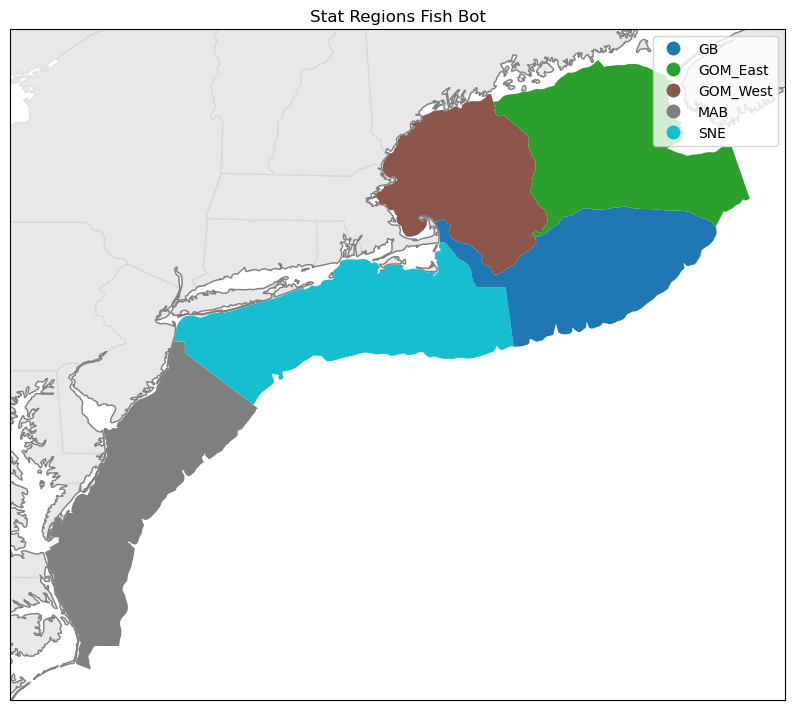

In [16]:
## Wow look at those areas
fig,ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': ccrs.PlateCarree()})

stat_areas.plot(
    column="Region",   # color by division
    legend=True,
    ax=ax
)

ax.add_feature(cfeature.STATES, color="lightgrey", alpha=0.5)
ax.add_feature(cfeature.COASTLINE,color='grey');
ax.set_title("Stat Regions Fish Bot")
plt.show()

#### Clipping the Doppio data the region shape files

In [17]:
stat_areas

,area,Region,geometry
0,5.770158,MAB,"POLYGON ((-74.71113 36.50517, -74.71232 36.501..."
1,6.227196,SNE,"POLYGON ((-73.20656 40.61663, -73.20523 40.617..."
2,4.762347,GB,"POLYGON ((-66.74085 40.75303, -66.74573 40.750..."
3,4.382310,GOM_West,"POLYGON ((-69.91489 42.02679, -69.98377 42.004..."
4,6.376634,GOM_East,"POLYGON ((-65.56925 42.16613, -65.68762 41.935..."


In [18]:
mab =       stat_areas[stat_areas['Region'] == 'MAB']
sne =       stat_areas[stat_areas['Region'] == 'SNE']
gb =        stat_areas[stat_areas['Region'] == 'GB']
gom_west =  stat_areas[stat_areas['Region'] == 'GOM_West']
gom_east =  stat_areas[stat_areas['Region'] == 'GOM_East']

In [19]:
mab_geom =      stat_areas.geometry.iloc[0]
sne_geom =      stat_areas.geometry.iloc[1]
gb_geom =       stat_areas.geometry.iloc[2]
gom_west_geom = stat_areas.geometry.iloc[3]
gom_east_geom = stat_areas.geometry.iloc[4]

mab_polygon =       Polygon(mab_geom)
sne_polygon =       Polygon(sne_geom)
gb_polygon =        Polygon(gb_geom)
gom_west_polygon =  Polygon(gom_west_geom)
gom_east_polygon =  Polygon(gom_east_geom)


In [ ]:
from shapely import vectorized

In [20]:
# flatten once
lat = bottemp['lat_rho'].values
lon = bottemp['lon_rho'].values

lat_flat = lat.ravel()
lon_flat = lon.ravel()
points = [Point(lon, lat) for lon, lat in zip(lon_flat, lat_flat)]

# store polygons
poly_dict = {
    "mab": mab_polygon,
    "sne": sne_polygon,
    "gb": gb_polygon,
    "gom_west": gom_west_polygon,
    "gom_east": gom_east_polygon
}

masked_datasets = {}

for name, poly in poly_dict.items():
    # build mask
    mask_flat = np.array([poly.covers(pt) for pt in points])
    mask_2d = mask_flat.reshape(lat.shape)
    
    # apply mask WITHOUT modifying original
    ds_masked = bottemp.copy()
    
    for var in ds_masked.data_vars:
        if {'eta_rho', 'xi_rho'}.issubset(ds_masked[var].dims):
            ds_masked[var] = ds_masked[var].where(mask_2d)
    
    masked_datasets[name] = ds_masked

In [24]:
mab_doppio      =   masked_datasets['mab']
sne_doppio      =   masked_datasets['sne']
gb_doppio       =   masked_datasets['gb']
gom_west_doppio =   masked_datasets['gom_west']
gom_east_doppio =   masked_datasets['gom_east']

In [ ]:
mab_doppio 

<xarray.Dataset> Size: 3GB
Dimensions:     (ocean_time: 6573, eta_rho: 106, xi_rho: 242)
Coordinates:
  * ocean_time  (ocean_time) datetime64[ns] 53kB 2007-01-02T12:00:00 ... 2024...
    lon_rho     (eta_rho, xi_rho) float64 205kB dask.array<chunksize=(106, 242), meta=np.ndarray>
    lat_rho     (eta_rho, xi_rho) float64 205kB dask.array<chunksize=(106, 242), meta=np.ndarray>
    s_rho       float64 8B -0.9875
Dimensions without coordinates: eta_rho, xi_rho
Data variables:
    temp        (ocean_time, eta_rho, xi_rho) float32 674MB dask.array<chunksize=(1, 106, 242), meta=np.ndarray>
    salt        (ocean_time, eta_rho, xi_rho) float32 674MB dask.array<chunksize=(1, 106, 242), meta=np.ndarray>
    z_rho2      (ocean_time, eta_rho, xi_rho) float64 1GB dask.array<chunksize=(1, 106, 242), meta=np.ndarray>
Attributes: (12/32)
    file:              doppio_avg_6933.nc
    format:            netCDF-4/HDF5 file
    Conventions:       CF-1.4, SGRID-0.3
    type:              ROMS/TOMS nonlinear model averages file
    title:             DopAnV3R3-ini2007 - ROMS DOPPIO 7km reanalysis (assimi...
    var_info:          ../../Data/varinfo1040t_daily.dat
    ...                ...
    compiler_flags:    -fp-model precise -heap-arrays -ip -O3 -traceback -che...
    tiling:            008x008
    history:           ROMS/TOMS, Version 3.9, Friday - January 24, 2025 -  3...
    ana_file:          ROMS/Functionals/ana_btflux.h
    CPP_options:       DOPPIO, ADD_FSOBC, ADD_M2OBC, ANA_BSFLUX, ANA_BTFLUX, ...
    summary:           doppio

In [39]:
mab_doppio = mab_doppio.dropna(dim='xi_rho', how='all')
mab_doppio = mab_doppio.dropna(dim='eta_rho', how='all')

KeyboardInterrupt: 

ERR: curl error: Timeout was reached
curl error details: 


In [28]:
mab_doppio_temp = mab_doppio.temp.to_dataframe()

In [33]:
mab_doppio_temp.dropna(subset='temp')

s_rho    lon_rho    lat_rho       temp
ocean_time          eta_rho xi_rho                                         
2007-01-02 12:00:00 37      29     -0.9875 -75.297845  35.204754  19.558058
                    38      28     -0.9875 -75.406747  35.212484  17.909433
                            29     -0.9875 -75.347410  35.253110  18.610453
                            36     -0.9875 -74.930381  35.536677  15.761298
                            37     -0.9875 -74.870567  35.577069  13.098582
...                                    ...        ...        ...        ...
2024-12-30 12:00:00 86      91     -0.9875 -73.964830  40.078274   9.824201
                            92     -0.9875 -73.900942  40.118043   9.681140
                            93     -0.9875 -73.836987  40.157778   9.614659
                    87      91     -0.9875 -74.016716  40.126986   8.836916
                            92     -0.9875 -73.952814  40.166778   9.358880

[7453782 rows x 4 columns]